Using a [random forest](https://datascience.stackexchange.com/questions/54751/when-to-use-random-forest). 

In [12]:
import os
import pandas as pd

# 1. Direct path to your system's global Kagglehub cache directory
kaggle_cache_path = "/Users/koenamukherjee/.cache/kagglehub/datasets/davidcariboo/player-scores/versions/677"
data_path = os.path.join(kaggle_cache_path, "players.csv")

# Ensure the file is physically verified before loading
if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"Could not locate players.csv at your cached location: {data_path}\n"
        f"Please run `import kagglehub; path = kagglehub.dataset_download('davidcariboo/player-scores')` "
        f"in a separate cell to verify the path."
    )

print(f"Connected to Kaggle cache at: {data_path}")


Connected to Kaggle cache at: /Users/koenamukherjee/.cache/kagglehub/datasets/davidcariboo/player-scores/versions/677/players.csv


In [13]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Point directly to your active Kagglehub cache directory
kaggle_cache_path = "/Users/koenamukherjee/.cache/kagglehub/datasets/davidcariboo/player-scores/versions/677"
data_path = os.path.join(kaggle_cache_path, "players.csv")

# 2. Load the dataset
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Could not locate players.csv at: {data_path}")
    
df = pd.read_csv(data_path)

# 3. Clean target and feature columns
df = df.copy()
df['market_value_in_eur'] = pd.to_numeric(df['market_value_in_eur'], errors='coerce')
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
df['position'] = df['position'].fillna('Unknown').astype(str).str.strip()

# 4. Filter for active professionals (worth >= €1 Million)
df = df[
    df['market_value_in_eur'].notna()
    & (df['market_value_in_eur'] >= 1_000_000)
    & df['date_of_birth'].notna()
].copy()

# 5. Create age feature (using 2026 as current year)
df['age'] = (2026 - df['date_of_birth'].dt.year).astype(int)

# 6. Define features and target (Target converted to Millions for readability)
features = ['age', 'position']
X = df[features]
y = df['market_value_in_eur'] / 1_000_000  

# 7. Split into train/test sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("--- DATA BOUNDARIES DEFINED ---")
print(f"Connected to cache at: {data_path}")
print(f"Training set size: {X_train.shape[0]} players")
print(f"Testing set size:  {X_test.shape[0]} players")


--- DATA BOUNDARIES DEFINED ---
Connected to cache at: /Users/koenamukherjee/.cache/kagglehub/datasets/davidcariboo/player-scores/versions/677/players.csv
Training set size: 6906 players
Testing set size:  1727 players


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Set up categorical preprocessing (handles position text)
preprocessor = ColumnTransformer(
    transformers=[
        ('position', OneHotEncoder(handle_unknown='ignore'), ['position'])
    ],
    remainder='passthrough'  # Keeps the 'age' column untouched
)

# 2. Bundle preprocessing and the model into a unified pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,          # Uses all CPU cores to compute faster
        min_samples_leaf=2  # Prevents overfitting on noise
    ))
])

# 3. Train the model
model_pipeline.fit(X_train, y_train)

# 4. Evaluate predictions
train_preds = model_pipeline.predict(X_train)
test_preds = model_pipeline.predict(X_test)

train_r2 = r2_score(y_train, train_preds)
test_r2 = r2_score(y_test, test_preds)
mae = mean_absolute_error(y_test, test_preds)

print("--- MODEL PERFORMANCE EVALUATION ---")
print(f"Train R² Score:               {train_r2:.3f}")
print(f"Test R² Score (Unseen Data):  {test_r2:.3f}")
print(f"Mean Absolute Error (MAE):    €{mae:.2f} Million")


--- MODEL PERFORMANCE EVALUATION ---
Train R² Score:               0.041
Test R² Score (Unseen Data):  0.025
Mean Absolute Error (MAE):    €6.13 Million


baseline model: can explain 2.5% of why a player is valuable. This makes sense because a random 25 year old who plays forward can range from 1mil Euros to Haaland (180mil Euros). Age and position cannot be used to quantify talent. 

In [15]:
## model reval

# Update your features list to include the club's league code
features = ['age', 'position', 'current_club_domestic_competition_id']

# Make sure to drop rows missing this new column
X = df[features].dropna()
y = df.loc[X.index, 'market_value_in_eur'] / 1_000_000  

# Split the data again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Bundle preprocessing and the model into a unified pipeline
# Update the preprocessor to encode BOTH text columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['position', 'current_club_domestic_competition_id'])
    ],
    remainder='passthrough'
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,          # Uses all CPU cores to compute faster
        min_samples_leaf=2  # Prevents overfitting on noise
    ))
])

# 3. Train the model
model_pipeline.fit(X_train, y_train)

# 4. Evaluate predictions
train_preds = model_pipeline.predict(X_train)
test_preds = model_pipeline.predict(X_test)

train_r2 = r2_score(y_train, train_preds)
test_r2 = r2_score(y_test, test_preds)
mae = mean_absolute_error(y_test, test_preds)

print("--- MODEL PERFORMANCE EVALUATION ---")
print(f"Train R² Score:               {train_r2:.3f}")
print(f"Test R² Score (Unseen Data):  {test_r2:.3f}")
print(f"Mean Absolute Error (MAE):    €{mae:.2f} Million")


--- MODEL PERFORMANCE EVALUATION ---
Train R² Score:               0.293
Test R² Score (Unseen Data):  0.119
Mean Absolute Error (MAE):    €5.25 Million


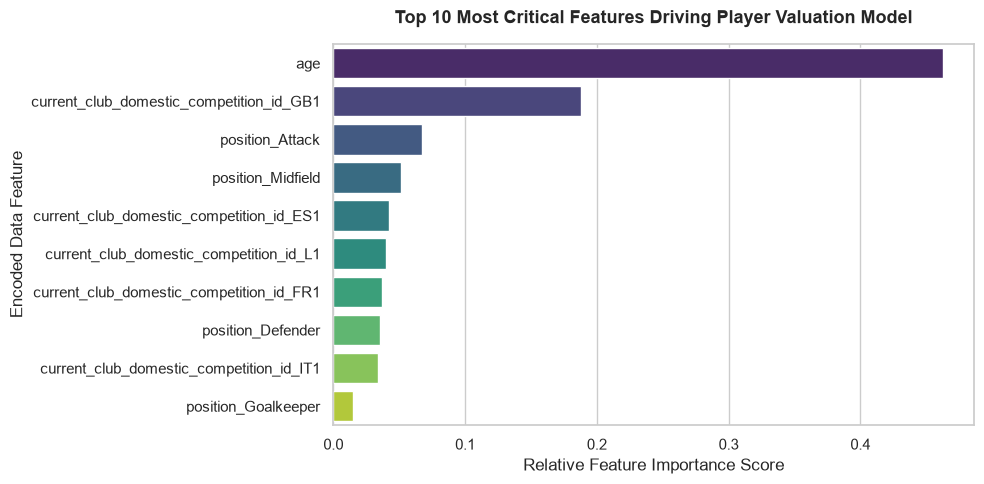

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract feature names from the OHE preprocessor step
cat_encoder = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_features = list(cat_encoder.get_feature_names_out(['position', 'current_club_domestic_competition_id']))
all_features = encoded_features + ['age']  # append the passthrough numerical feature

# 2. Get the raw importance scores from the random forest regressor
importances = model_pipeline.named_steps['regressor'].feature_importances_

# 3. Create a clean DataFrame of features and their respective importance weightings
fi_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(10)  # Top 10 most impactful rules

# 4. Plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)

plt.title('Top 10 Most Critical Features Driving Player Valuation Model', fontsize=13, weight='bold', pad=15)
plt.xlabel('Relative Feature Importance Score')
plt.ylabel('Encoded Data Feature')
plt.tight_layout()
plt.show()
